# Data Preprocessing Graded Assignment
---


# Given Business Scenario:

The task is to work as a data scientist for StaySmart Hotels. We must build a predictive churn risk model for the business take proactive actions like offering reminders, discounts, etc.


# Chosen Target:
**Option A:** Predict is_canceled (binary classification)

Function `is_canceled` produces the final output of the churn model. It classifies whether a customer is going to cancel their booking, or not. It is similar to classifying emails as spam/ham, and uses the input features to predict a binary outcome of 0 (not churned), or 1 (churned). Multiclass Regression on the other hand, categorizes data into one of three or more exclusive classes. Binary Classification is simpler and preferred over Multiclass Regression via Binning, because the latter involves heavy conversions of continuous values into discrete intervals, which is computationally expensive.

In a nutshell, Binary Classification should be preferred for simple positive/negative, or yes/no questions, while Multiclass Regression should be preferred to choose among multiple distinct categories.


---



# Setup - Installing Libraries and Loading Dataset


The cell below installs all the libraries essential for the project, and loads the hotel_booking dataset. Run this cell before anything else.


In [1]:
!pip install prettytable

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, RobustScaler, PowerTransformer, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.datasets import make_classification
from scipy.spatial.distance import pdist, cdist
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.inspection import permutation_importance
from prettytable import PrettyTable

print("Libraries loaded successfully!")

url = 'https://raw.githubusercontent.com/swapnilsaurav/Dataset/refs/heads/master/hotel_bookings.csv'
df = pd.read_csv(url)

print("Dataset loaded successfully!")
df

Libraries loaded successfully!
Dataset loaded successfully!


,id,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,1,Resort Hotel,0.0,342.0,2015,July,27.0,1.0,0.0,0.0,...,No Deposit,NaN,NaN,0.0,Transient,0.00,0.0,0.0,Check-Out,01-07-2015
1,2,Resort Hotel,0.0,737.0,2015,July,27.0,1.0,0.0,0.0,...,No Deposit,NaN,NaN,0.0,Transient,0.00,0.0,10.0,Check-Out,01-07-2015
2,3,Resort Hotel,0.0,7.0,2015,July,27.0,1.0,0.0,1.0,...,No Deposit,NaN,NaN,0.0,Transient,75.00,0.0,0.0,Check-Out,02-07-2015
3,4,Resort Hotel,0.0,13.0,2015,July,27.0,1.0,0.0,1.0,...,No Deposit,304.0,NaN,0.0,Transient,75.00,0.0,0.0,Check-Out,02-07-2015
4,5,Resort Hotel,0.0,14.0,2015,July,27.0,1.0,0.0,2.0,...,No Deposit,240.0,NaN,0.0,Transient,98.00,0.0,1.0,Check-Out,03-07-2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,119386,City Hotel,0.0,23.0,2017,August,35.0,30.0,2.0,5.0,...,No Deposit,394.0,NaN,0.0,Transient,96.14,0.0,0.0,Check-Out,06-09-2017
119386,119387,City Hotel,0.0,102.0,2017,August,35.0,31.0,2.0,5.0,...,No Deposit,9.0,NaN,0.0,Transient,225.43,0.0,2.0,Check-Out,07-09-2017
119387,119388,City Hotel,0.0,34.0,2017,August,35.0,31.0,2.0,5.0,...,No Deposit,9.0,NaN,0.0,Transient,157.71,0.0,4.0,Check-Out,07-09-2017
119388,119389,City Hotel,0.0,109.0,2017,August,35.0,31.0,2.0,5.0,...,No Deposit,89.0,NaN,0.0,Transient,104.40,0.0,0.0,Check-Out,07-09-2017


In [3]:
def create_table(X):
  table = PrettyTable()
  table.field_names = X.columns.tolist()
  for row in X.itertuples(index=False):
    table.add_row(row)

  return table

In [4]:
def display_dataframe(X):
  no_rows = 10
  table = PrettyTable()
  table.field_names = X.columns.tolist()
  for row in X.head(no_rows).itertuples(index=False):
    table.add_row(row)

  return table

In [5]:
def display_series(series):
  no_rows = 10
  table = PrettyTable()
  table.field_names = ["Feature", "Score"]

  for idx, val in series.head(no_rows).items():
      table.add_row([idx, round(val, 4)])

  return table

# Exploring the Dataset


---



In [6]:
# shape - tells the shape, i.e, number of rows and columns of the dataset
print(f"df.shape: {df.shape}\n")
print("-" * 80 + "\n")

# .head() - retrieves the first 5 rows of the dataset
print("df.head():\n")
print(create_table(df.head()))
print("-" * 80 + "\n")

# .tail() - retrieves the last 5 rows of the dataset
print("\ndf.tail():\n")
print(create_table(df.tail()))
print("-" * 80 + "\n")

# .info() - shows the structure and metadata of the dataset
print("\ndf.info():\n")
print(df.info())
print("-" * 80 + "\n")

# datatype summary of each column
dtype_summary = pd.DataFrame(
    {
        "columns": df.columns,
        "dtypes": [str(df[c].dtype) for c in df.columns],
        "non_null_count": [df[c].notna().sum() for c in df.columns],
        "null_count": [df[c].isna().sum() for c in df.columns],
        "unique_values": [df[c].nunique(dropna=True) for c in df.columns]
    }
)
print("\ndatatype summary of each column:\n")
print(create_table(dtype_summary))
print("-" * 80 + "\n")

# descriptive statistics of both numeric and categorical columns

# 1. numeric columns
numeric_cols = df.select_dtypes(include="number").columns.tolist()
if numeric_cols:
  print("---Numeric Columns:---")
  print(f"List of Numeric Columns: {numeric_cols}")
  print(f"Number of Numeric Columns: {len(numeric_cols)}")
  print("\ndf.describe():\n")
  print(create_table(df[numeric_cols].describe()))
else:
  print("no numeric columns found")

# 2. categorical columns
categorical_cols = df.select_dtypes(include=["object", "string", "category", "bool"]).columns.tolist()
if categorical_cols:
 print("\n\n---Categorical/Text/Boolean Columns:---")
 print(f"List of Categorical Columns: {categorical_cols}")
 print(f"Length of Categorical Columns: {len(categorical_cols)}")
else:
  print("no categorical columns found")

print("-" * 80 + "\n")


df.shape: (119390, 33)

--------------------------------------------------------------------------------

df.head():

+----+--------------+-------------+-----------+-------------------+--------------------+--------------------------+---------------------------+-------------------------+----------------------+--------+----------+--------+------+---------+----------------+----------------------+-------------------+------------------------+--------------------------------+--------------------+--------------------+-----------------+--------------+-------+---------+----------------------+---------------+------+-----------------------------+---------------------------+--------------------+-------------------------+
| id |    hotel     | is_canceled | lead_time | arrival_date_year | arrival_date_month | arrival_date_week_number | arrival_date_day_of_month | stays_in_weekend_nights | stays_in_week_nights | adults | children | babies | meal | country | market_segment | distribution_channel | is

# Task 1 -  Baseline + “What is a Feature?”


---



In [7]:
# Step 1 - Creating a copy of df
df_copy = df.copy()
df_copy = df_copy.dropna(subset=["is_canceled"])

# Step 2 - Performing test-train split
X = df_copy.drop(["is_canceled","reservation_status", "reservation_status_date", "id"], axis=1)
y = df_copy["is_canceled"]

X_train_baseline, X_test_baseline, y_train_baseline, y_test_baseline = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3 - Categorizing Numeric and Categorical columns
num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'string', 'bool', 'category']).columns.tolist()
print(f"num cols in stage 1: {num_cols}\ncat cols in stage 1: {cat_cols}\n")

# Step 4 - Creating Simple Preprocessors
num_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoding", OneHotEncoder(handle_unknown="ignore"))
])

# Step 4 - Creating ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ("num", num_preprocessor, num_cols),
    ("cat", cat_preprocessor, cat_cols)
])

# Step 5 - Building Baseline Model Pipeline
base_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression())
])

# Step 6 - Train the Model
base_model.fit(X_train_baseline, y_train_baseline)

# Step 7 - Test the Model
y_pred_baseline = base_model.predict(X_test_baseline)

accuracy = accuracy_score(y_test_baseline, y_pred_baseline)

y_prob_baseline = base_model.predict_proba(X_test_baseline)[:, 1]
roc_auc = roc_auc_score(y_test_baseline, y_prob_baseline)

conf_matrix = confusion_matrix(y_test_baseline, y_pred_baseline)

f1 = f1_score(y_test_baseline, y_pred_baseline)

print(f"\n\naccuracy: {accuracy}\nroc_auc: {roc_auc}\nconf_matrix:\n{conf_matrix}\nf1: {f1}\n")

num cols in stage 1: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
cat cols in stage 1: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(




accuracy: 0.8131177751717206
roc_auc: 0.8957121492804199
conf_matrix:
[[13747  1261]
 [ 3201  5667]]
f1: 0.7175234236515573



# What is a Feature?
A feature is a characteristic that helps a model predict the target variable. They can be measurable, or labeled, i.e, numeric (e.g, `adults`, `is_repeated_guest`, `total_of_special_requests`)  or categorical (e.g, `country`, `arrival_date_month`, `assigned_room_type`). The selection and engineering of good features is crucial to obtain an accurate prediction.

**Examples of Good and Bad features from the dataset**

What exactly makes a feature good? If a feature holds a strong meaningful relationship with the target variable, and steers the prediction to the right direction, it is considered a good feature. Good features are relevant, and help the model generalize. Bad features add noise, bias, or redundancy. They are irrelevant, and highly correlated. Bad features alter the expected accuracy of the model.

For example, from the dataset:
`is_repeated_guest` and `previous_cancellations` are good features as they show loyalty to the company. `lead_time` is the difference between the reservation & arrival dates, thus, shorter the lead_time, the lesser a customer is to cancel.

`reservation_status` and `reservation_status_date` leak information about the target as they are highly correlated to it, causing extremely high accuracy and overfitting. Also, `company` is a feature with 95% NaN values. Imputing such a large number of values would make the model unreliable, and the feature must be dropped.

# Task 2 - Curse of Dimensionality Demo


---



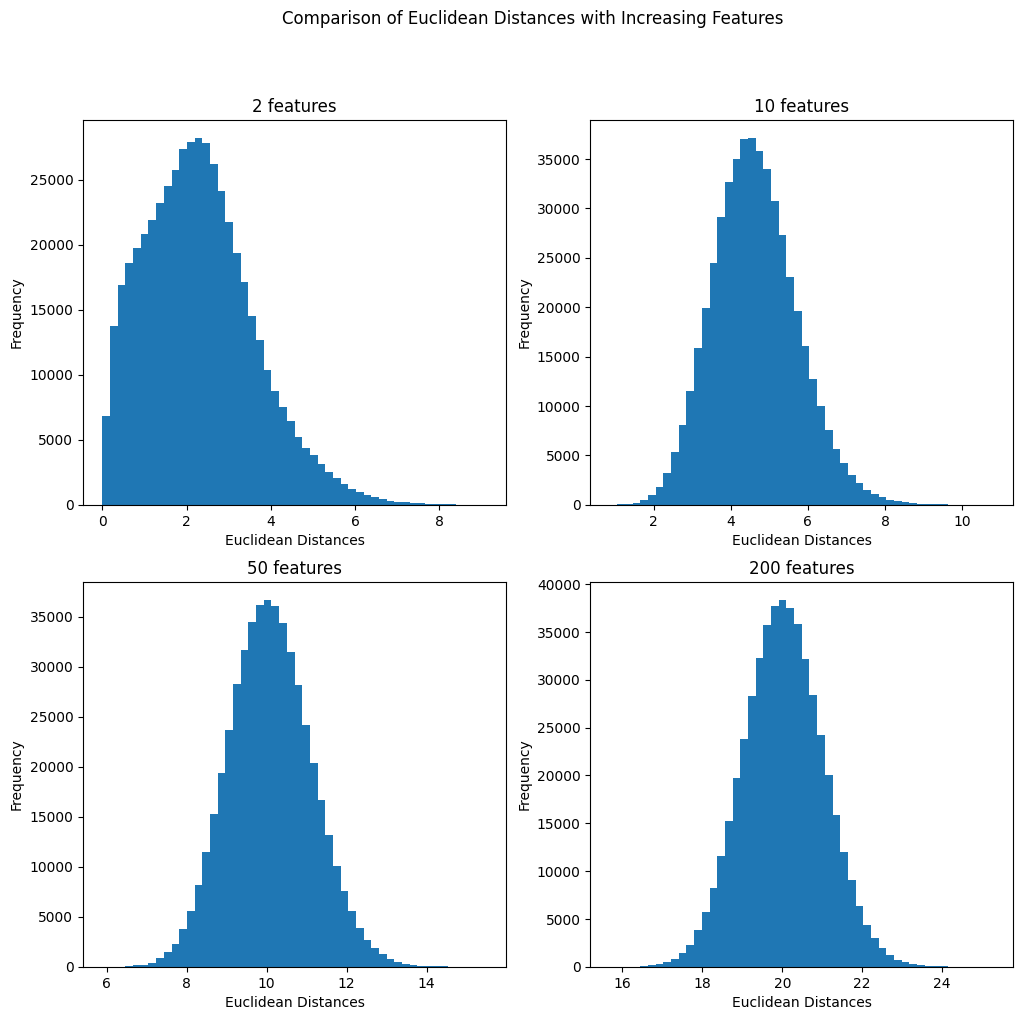

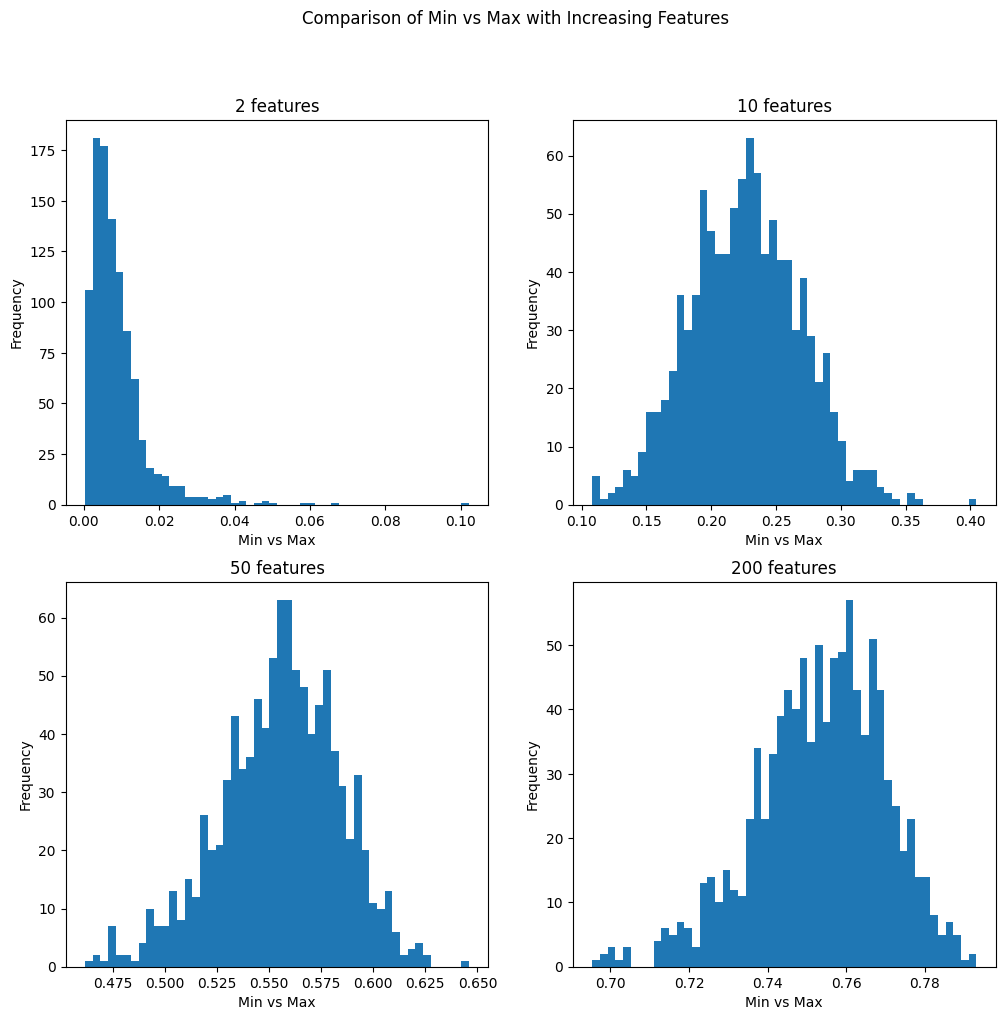

In [8]:
# Using a user-defined function 'create_synthetic' to avoid redundant code
def create_synthetic(no_features, no_points):
  X, y = make_classification(
      n_samples = 5000,
      n_features = no_features,
      #n_informative = 2,
      n_redundant = 0,
      random_state = 42
  )
  random_indices = np.random.choice(X.shape[0], no_points, replace=False)
  random_points = X[random_indices]
  return random_points

no_features = [2, 10, 50, 200]
no_points = 1000 # change the number of points here optionally
distances = []
dist_matrix = []
ratios = []

def plot_graph(metric, X):
  fig, axs = plt.subplots(2, 2, figsize=(12, 11))
  count = 0
  for i in range(0, 2):
    for j in range(0, 2):
      axs[i, j].hist(X[count], bins=50)
      axs[i, j].set_title(f"{no_features[count]} features")
      axs[i, j].set_xlabel(f"{metric}")
      axs[i, j].set_ylabel("Frequency")
      count += 1

  fig.suptitle(f"Comparison of {metric} with Increasing Features")
  plt.show()
  print("\n\n")

for i in no_features:
  points = create_synthetic(i, no_points)
  distances.append(pdist(points)) # compute pairwise distances of selected random points

  dist_matrix = cdist(points, points, metric='euclidean')
  dist_matrix_min = dist_matrix.copy()
  np.fill_diagonal(dist_matrix_min, np.inf)
  min_dist = np.min(dist_matrix_min, axis=1)

  dist_matrix_max = dist_matrix.copy()
  np.fill_diagonal(dist_matrix_max, 0)
  max_dist = np.max(dist_matrix_max, axis=1)

  ratio = min_dist / max_dist
  ratios.append(ratio)

plot_graph("Euclidean Distances", distances)
plot_graph("Min vs Max", ratios)


# Observed Pattern


*   The code was tested on multiple number of points - 10, 100, 200, 500, 1000, 2000. A minimum of 500 points are necessary to see the difference between each subplot. After that, the plots stabilize and show similar distributions
*   The distribution is centered along the mean. So, as the dimensions increase from 2, to 10, to 50, to 200, so will the distance between points. Thus, the mean shifts further to the right until it reaches the center.
*    The lesser the number of dimensions, the more the width and even spread. As dimensions increase, it takes on more of a bell-shape.
*    Each bar represents the number of point pairs with a distance in that range. In the higher dimensions, almost every point has the same distance with each other.

**Why high dimension makes learning harder**

When dimensions are increased, one expects the accuracy of the model to go up. But:
*   Increasing the number of features adds noise, and introduces multicollinearity.
*   With large dimensions, the distance between the nearest and furthest point becomes almost the same, rendering distance-based algorithms pointless. In smaller dimensions, two points may actually be near or far, but that can't be distinguished under large dimensions. Two customers may have the exact same details, but the distance between them is still far.
*   Available data points become sparse, and spread out. Heavy loads of data must be collected to work with large dimensions, and that increases computation cost
*   Models learn the patterns in the available sparse data, and perform poorly on unseen data. This is overfitting.

**Link to feature engineering necessity**

Feature engineering combats the curse of dimensionality by transforming, handpicking, or extracting features with meaningful relationships to the target variable. This reduces dimensionality, computational cost, and prevents overfitting. For example:

- Feature Selection: Dropping the `company` feature can remove computational burden, as it is very sparse.
- Feature Extraction: The features arrival date, month, year, day, don't provide much information on their own. Combining them into a feature `peak/off season`, provides better idea.

# Task 3 - Numeric Preprocessing


---

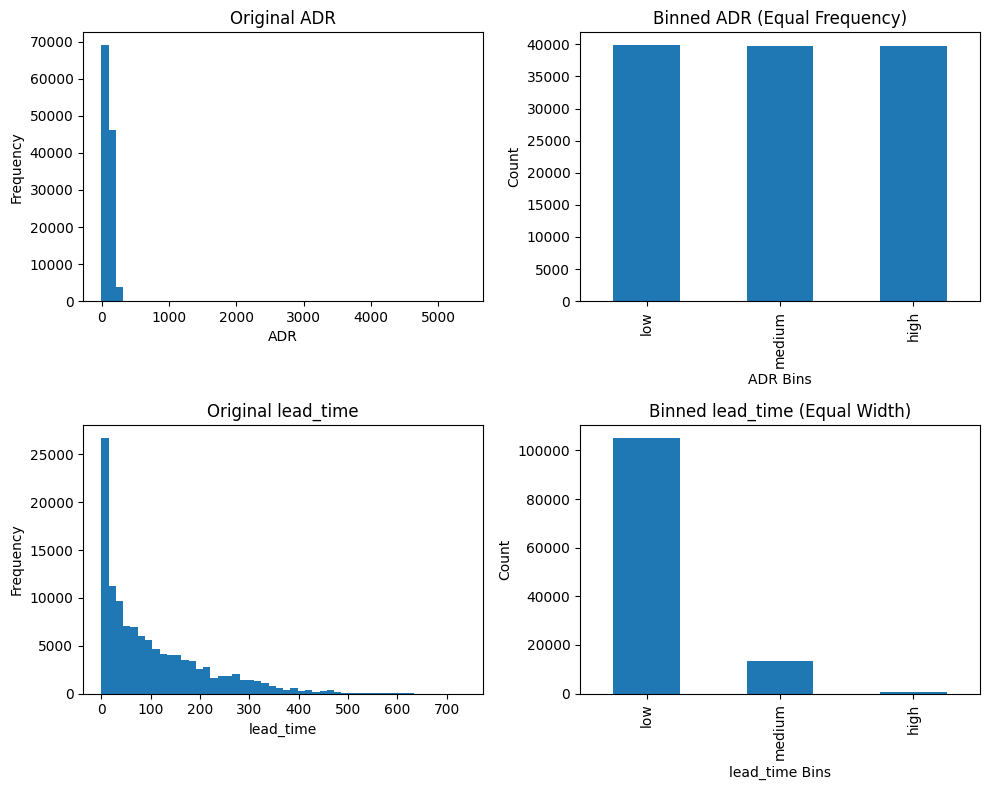

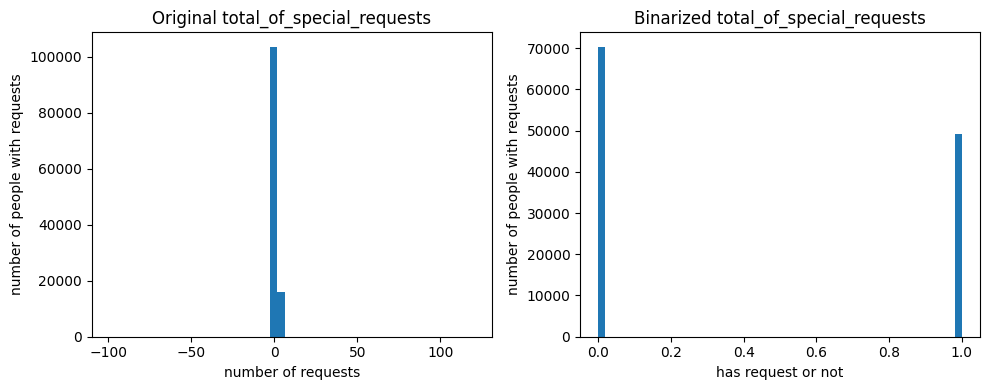



                                            mean         std         iqr
scaler   column                                                         
Original adr                        1.018298e+02   50.534788   56.720000
         lead_time                  1.040143e+02  106.866472  142.000000
         total_of_special_requests  6.026840e-01    3.393265    1.000000
MinMax   adr                        2.001520e-02    0.009347    0.010491
         lead_time                  1.411320e-01    0.145002    0.192673
         total_of_special_requests  4.548068e-01    0.015494    0.004566
Standard adr                       -5.523586e-16    1.000004    1.122400
         lead_time                 -5.713864e-18    1.000004    1.328767
         total_of_special_requests  5.714055e-18    1.000004    0.294703
Robust   adr                        1.290514e-01    0.890952    1.000000
         lead_time                  2.465793e-01    0.752581    1.000000
         total_of_special_requests  6.026840e-01 

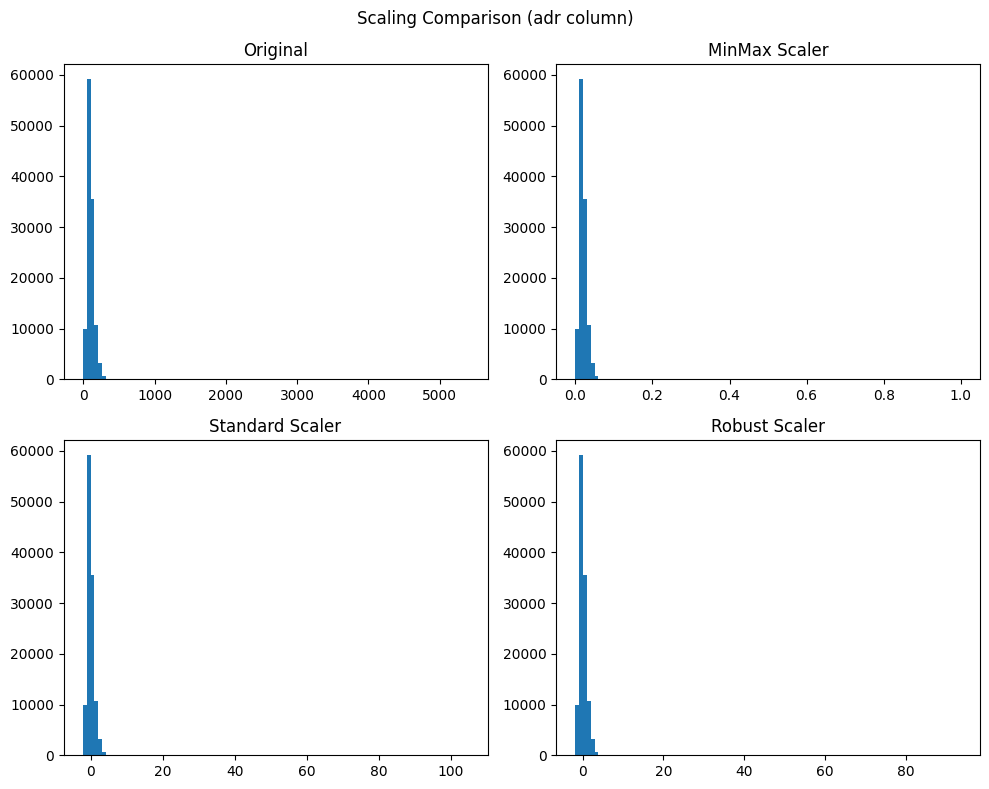

In [9]:
# 1. Binning / Discretization
def apply_binning():
  df_copy['adr_binned'] = pd.qcut(df_copy['adr'], q=3, labels=['low', 'medium', 'high']) # apply equal frequency binning
  df_copy['lead_time_binned'] = pd.cut(df_copy['lead_time'], bins=3,  labels=['low', 'medium', 'high'])

  # visualization
  fig, axs = plt.subplots(2, 2, figsize=(10, 8))

  axs[0, 0].hist(df_copy['adr'], bins=50)
  axs[0, 0].set_title("Original ADR")
  axs[0, 0].set_xlabel("ADR")
  axs[0, 0].set_ylabel("Frequency")

  df_copy['adr_binned'].value_counts().sort_index().plot(kind='bar', ax=axs[0, 1])
  axs[0, 1].set_title("Binned ADR (Equal Frequency)")
  axs[0, 1].set_xlabel("ADR Bins")
  axs[0, 1].set_ylabel("Count")

  axs[1, 0].hist(df_copy['lead_time'], bins=50)
  axs[1, 0].set_title("Original lead_time")
  axs[1, 0].set_xlabel("lead_time")
  axs[1, 0].set_ylabel("Frequency")

  df_copy['lead_time_binned'].value_counts().sort_index().plot(kind='bar', ax=axs[1, 1])
  axs[1, 1].set_title("Binned lead_time (Equal Width)")
  axs[1, 1].set_xlabel("lead_time Bins")
  axs[1, 1].set_ylabel("Count")

  plt.tight_layout()
  plt.show()

# 2. Binarization
def apply_binarization():
  df_copy['has_special_requests'] = (df_copy['total_of_special_requests'] > 0).astype(int)

  fig, axs = plt.subplots(1, 2, figsize=(10, 4))

  axs[0].hist(df_copy['total_of_special_requests'], bins=50)
  axs[0].set_title("Original total_of_special_requests")
  axs[0].set_xlabel("number of requests")
  axs[0].set_ylabel("number of people with requests")

  axs[1].hist(df_copy['has_special_requests'], bins=50)
  axs[1].set_title("Binarized total_of_special_requests")
  axs[1].set_xlabel("has request or not")
  axs[1].set_ylabel("number of people with requests")

  plt.tight_layout()
  plt.show()

# 3. Scaling
def compute_stats(scaled):
  q1 = scaled.quantile(0.25)
  q3 = scaled.quantile(0.75)

  return{
      "mean": scaled.mean(),
      "std": scaled.std(),
      "iqr": q3 - q1
  }

def apply_scaling():
  scale_cols = ['adr', 'lead_time', 'total_of_special_requests']
  scalers = {
      "MinMax": MinMaxScaler(),
      "Standard": StandardScaler(),
      "Robust": RobustScaler()
  }
  rows = []
  scaled_data = {}

  for col in scale_cols:
      stats = compute_stats(df_copy[col])
      stats['scaler'] = 'Original'
      stats['column'] = col
      rows.append(stats)

  for name, scaler in scalers.items():
      scaled_array = scaler.fit_transform(df_copy[scale_cols])
      scaled_df = pd.DataFrame(scaled_array, columns=scale_cols)
      scaled_data[name] = scaled_df['adr'].values  # store only adr for plots
      for col in scale_cols:
          stats = compute_stats(scaled_df[col])
          stats['scaler'] = name
          stats['column'] = col
          rows.append(stats)

  comparison_table = pd.DataFrame(rows).set_index(['scaler', 'column'])
  print(comparison_table)
  print("\n\n")

  fig, axs = plt.subplots(2, 2, figsize=(10, 8))
  fig.suptitle("Scaling Comparison (adr column)")

  axs[0, 0].hist(df_copy['adr'], bins=100)
  axs[0, 0].set_title("Original")

  axs[0, 1].hist(scaled_data['MinMax'], bins=100)
  axs[0, 1].set_title("MinMax Scaler")

  axs[1, 0].hist(scaled_data['Standard'], bins=100)
  axs[1, 0].set_title("Standard Scaler")

  axs[1, 1].hist(scaled_data['Robust'], bins=100)
  axs[1, 1].set_title("Robust Scaler")

  plt.tight_layout()
  plt.show()

apply_binning()
print("\n")
apply_binarization()
print("\n")
apply_scaling()

# Which Scaler is the best and why?

The purpose of scaling is to normalize the ranges of features, to ensure the magnitude of one feature doesn't dominate the remaining ones. A Scaler is chosen on the basis of the dataset at hand. RobustScaler is best used when there are significant number of outliers, StandardScaler is used to obtain a normal distribution and center the data with Mean = 0, and Std ~ 1, MinMaxScaler is used to constrain the values to a range, usually 0-1.

In this context, MinMaxScaler pushes values extremely close to 0, instead of lying between [0,1]. This shows extreme sensitivity to outliers. StandardScaler shows a mean of 0, and std of 1, confirming correct transformation. But the problem with StandardScaler as well, is sensitivity to outliers. The mean would be pushed further right/left, distorting the distribution

Finally, RobustScaler uses median and IQR, which are resistant to outliers, because median and IQR are dependent on the relative position of data over their magnitude. Both focus on the middle part of the data, median looking for the middle point and IQR focusing on the middle 50%, making them unaffected by outliers outside this range. The IQR for RobustScaler is 1, matching the expected outcome.

In conclusion, both StandardScaler and RobustScaler fit the dataset well, except RobustScaler has one big advantage over StandardScaler - and that is its resistance to outliers. So, RobustScaler can be deemed the best. For a model like KNN, scaling is crucial in order to preserve the relationships of the features, and ensure magnitude doesn't dominate the model's predictions.

# Task 4 - Distance/Proximity Metrics & Impact


In [10]:
features = ['adr', 'lead_time', 'stays_in_week_nights', 'is_repeated_guest', 'previous_cancellations', 'total_of_special_requests']
df_model = df_copy[features + ["is_canceled"]].dropna()

X = df_model[features]
y = df_model["is_canceled"]

X_train_metrics, X_test_metrics, y_train_metrics, y_test_metrics = train_test_split(
    X, y, test_size = 0.2, random_state=42
)
results = {}

def evaluate_model(scaler=None, metric="euclidean"):
  if scaler:
    X_training = scaler.fit_transform(X_train_metrics)
    X_testing = scaler.transform(X_test_metrics)
  else:
    X_training = X_train_metrics
    X_testing = X_test_metrics

  model = KNeighborsClassifier(n_neighbors = 10, metric = metric)
  model.fit(X_training, y_train_metrics)
  y_pred = model.predict(X_testing)

  if scaler:
    fstring = f"{scaler}_{metric}"
  else:
    fstring = f"Original_{metric}"
  results[fstring] = {
      "accuracy": accuracy_score(y_test_metrics, y_pred),
      "f1": f1_score(y_test_metrics, y_pred)
  }
  return

# No Scaling
evaluate_model(scaler=None, metric="euclidean")
evaluate_model(scaler=None, metric="manhattan")
evaluate_model(scaler=None, metric="cosine")
# Standard Scaler
evaluate_model(scaler=StandardScaler(), metric="euclidean")
evaluate_model(scaler=StandardScaler(), metric="manhattan")
evaluate_model(scaler=StandardScaler(), metric="cosine")
# Robust Scaler
evaluate_model(scaler=RobustScaler(), metric="euclidean")
evaluate_model(scaler=RobustScaler(), metric="manhattan")
evaluate_model(scaler=RobustScaler(), metric="cosine")

df_results = pd.DataFrame(results).T
df_results



,accuracy,f1
Original_euclidean,0.768596,0.636728
Original_manhattan,0.769224,0.639916
Original_cosine,0.773580,0.636889
StandardScaler()_euclidean,0.788155,0.671942
StandardScaler()_manhattan,0.788407,0.672033
StandardScaler()_cosine,0.789956,0.673651
RobustScaler()_euclidean,0.789621,0.673471
RobustScaler()_manhattan,0.789412,0.673252
RobustScaler()_cosine,0.783716,0.664108


**How results change**

We start with our unscaled data, and compute the euclidean, manhattan and cosine distances on them. The accuracy of all three is around 76-77%, and f1 score around 63-64%. We earlier concluded that StandardScaler and RobustScaler are the best possible choices for our dataset. So, accuracy using StandardScaler jumps up to 78-79%, and f1 score significantly improves up to 67%. The statistics are similar with RobustScaler, with accuracy going up to 78-79% like StandardScaler, and f1 score of 66-67%.

**Why scaling changes learning?**

Scaling is highly crucial, especially for distance-based models like K-Nearest Neighbors. Features with large magnitudes, but potentially meaningless relationships, can dominate the calculation, and the smaller features are ignored. Scaling combats this by normalizing each value, so they are all comparable.

**Observations about sensitivity to outliers**

Metrics like euclidean and manhattan distances are sensitive to outliers due to their magnitude-dependent behavior, meanwhile cosine similarity is purely direction based to examine the similarity of two points, and is resistant to outliers. Thus, in the presence of outliers, cosine similarity is always guaranteed to produce better scores.

Both StandardScaler and RobustScaler have extremely close to each other, with RobustScaler outperforming StandardScaler by ~0.001 points. This shows the presence of outliers, but not significant enough to cause heavy skewing of the data.

# Task 5 -  End-to-End Numeric Pipeline
---



In [11]:
# Step 1 - Choosing the features
transform_cols = ['lead_time', 'adr', 'days_in_waiting_list']
other_num_cols = list(set(num_cols) - set(transform_cols))
cat_cols = ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

# Step 2 - Creating Seperate Preprocessors
transform_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer(method="yeo-johnson")),
    ("scaler", StandardScaler())
])

normal_num_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehotencoder", OneHotEncoder(handle_unknown="ignore"))
])

# Step 3 - Load Preprocessors into ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ("num", normal_num_preprocessor, other_num_cols),
    ("cat", cat_preprocessor, cat_cols),
    ("transf", transform_preprocessor, transform_cols)
])

# Step 4 - Create the Model Pipeline
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier())
])

# Step 5 - Computing cross_val_score
X = df_copy[num_cols + cat_cols]
y = df_copy['is_canceled']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X, y, cv=cv)

print(f"Scores: {scores}")


Scores: [0.82572458 0.82371419 0.82312783 0.82735802 0.82522198]


# Task 6 - Feature Extraction

---



In [12]:
# 1. Date/Time Features

def get_season(month):
  if month in ['December','January', 'February']:
    return "winter"
  elif month in ['March', 'April', 'May']:
    return "summer"
  elif month in ['June', 'July', 'August']:
    return "monsoon"
  elif month in ['September', 'October', 'November']:
    return "autumn"
  else:
    return "not available"

df_copy['arrival_date_season'] = df_copy['arrival_date_month'].apply(get_season)

df_copy['arrival_date_day_of_month'] = df_copy['arrival_date_day_of_month'].fillna(1)
df_copy['arrival_date_weekend_flag'] = pd.to_datetime(
    df_copy['arrival_date_year'].astype(int).astype(str) + '-' +
    df_copy['arrival_date_month'].astype(str) + '-' +
    df_copy['arrival_date_day_of_month'].astype(int).astype(str),
    format='%Y-%B-%d'
).dt.weekday >= 5
df_copy['arrival_date_weekend_flag'] = df_copy['arrival_date_weekend_flag'].astype(int)

extracted_cols = ['arrival_date_weekend_flag', 'arrival_date_season']
print("New Columns after DateTime Extraction: \n")
print(display_dataframe(df_copy[extracted_cols]))
print("-"*70)

# 2. Text Features
df_copy['country'] = df_copy['country'].astype(str)
tfidf = TfidfVectorizer()

sample = df_copy['country'].head(20)
X_tfidf = tfidf.fit_transform(sample)

tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns = tfidf.get_feature_names_out())
print("\nTfidfVectorizing of country: \n")
print(display_dataframe(tfidf_df))
print("-"*70)

# 3. Categorical Feature Encoding

# 3.1 - Comparison with TfIdfVectorizer
sample = df_copy[["country"]].head(20)
ohe = OneHotEncoder(sparse_output=False)
X_onehot_country = ohe.fit_transform(sample)

ohe_df_country = pd.DataFrame(X_onehot_country, columns = ohe.get_feature_names_out())
print("\nOne-Hot Encoding of country:\n")
print(display_dataframe(ohe_df_country))
print("-"*70)

# 3.2 - One Hot Encoding 'hotel'
random_sample = df_copy[['hotel']].sample(n=20, random_state=42)
X_onehot_hotel = ohe.fit_transform(random_sample)

ohe_df_hotel = pd.DataFrame(X_onehot_hotel, columns = ohe.get_feature_names_out())
print("\nOne-Hot Encoding of hotel:\n")
print(display_dataframe(ohe_df_hotel))
print("-"*70)


New Columns after DateTime Extraction: 

+---------------------------+---------------------+
| arrival_date_weekend_flag | arrival_date_season |
+---------------------------+---------------------+
|             0             |       monsoon       |
|             0             |       monsoon       |
|             0             |       monsoon       |
|             0             |       monsoon       |
|             0             |       monsoon       |
|             0             |       monsoon       |
|             0             |       monsoon       |
|             0             |       monsoon       |
|             0             |       monsoon       |
|             0             |       monsoon       |
+---------------------------+---------------------+
----------------------------------------------------------------------

TfidfVectorizing of country: 

+-----+-----+-----+-----+-----+-----+
| esp | fra | gbr | irl | prt | usa |
+-----+-----+-----+-----+-----+-----+
| 0.0 | 0.0 | 

**Extracted Features**

A list of all the extracted features according to their categories are:

*   Date/Time: `reservation_status_weekend_flag`, `reservation_status_season`
*   Text: `country`
*   Categorical Feature Encoding: `country`, `hotel`


**Why each feature could influence the target:**



1.   `arrival_date_weekend_flag` - Weekdays are usually booked by customers on work/business trips, and are less likely to be canceled. Weekends are usually booked by customers on vacation, and may abruptly cancel due to plan changes.
2.   `arrival_date_season` - Bookings tend to peak in summer, and demand rises. Competition for high-rated hotels is high, and customers tend to hold on to their bookings. And monsoon generally sees lower demand due to travel restrictions and unstable weather. Customers are more likely to cancel.
3.   `country (tfidf)` - For the lack thereof text features, the country column is used as pseudo text to perform TF-IDF Vectorizing for demonstration. It is compared with One Hot Encoding.
4.   `country (ohe)` - Each country shares different booking cultures, and cancellation conditions. International travelers coming from far distances are less likely to cancel than local travelers who can rebook.
5.   `hotel` - Resort hotels are generally booked for leisure and vacation with large lead times, while city hotels are preferred for work trips with proximity to businesses with shorter lead times.



# Task 7 - Feature Construction


---



In [13]:
# 1. Ratio Features
# 1.1 children + babies-to-adult ratio
df_copy['babies'] = df_copy['babies'].fillna(0)
df_copy['children'] = df_copy['children'].fillna(0)
df_copy['adults'] = df_copy['adults'].fillna(df_copy['adults'].median())

df_copy['children_ratio'] = (df_copy['children'] + df_copy['babies'])/(df_copy['adults'] + 1)
print("Child-to-Adult ratio:\n")
print(display_series(df_copy['children_ratio']))
print("-"*70)

# 1.2 special requests per night
df_copy = df_copy.reset_index(drop=True)
df_copy = df_copy.loc[:, ~df_copy.columns.duplicated()]

df_copy['stays_in_weekend_nights'] = df_copy['stays_in_weekend_nights'].fillna(0)
df_copy['stays_in_week_nights'] = df_copy['stays_in_week_nights'].fillna(0)

df_copy['total_nights'] = df_copy['stays_in_weekend_nights'] + df_copy['stays_in_week_nights']
df_copy['avg_special_requests'] = (df_copy['total_of_special_requests'])/(df_copy['total_nights'] + 1)
print("Average Special Requests per Night ratio:\n")
print(display_series(df_copy['avg_special_requests']))
print("-"*70)

# 2. Interaction Features
# 2.1 lead_time & adr interaction
df_copy['adr'] = df_copy['adr'].fillna(df_copy['adr'].median())

df_copy['adr_leadtime_interaction'] = df_copy['lead_time'] * df_copy['adr']
print("Booking Price and Booking-Arrival Gap Interaction:\n")
print(display_series(df_copy['adr_leadtime_interaction']))
print("-"*70)

# 2.2 booking_changes & days_in_waiting_list
df_copy['changes_waiting_interaction'] = (df_copy['booking_changes'] + 1) * (df_copy['days_in_waiting_list'] + 1)
print("Booking Changes and Waiting Days Interaction:\n")
print(display_series(df_copy['changes_waiting_interaction']))
print("-"*70)

# 3. Aggregated Features
# 3.1 average adr by country
df_model = df_copy.copy()
X = df_model.drop("is_canceled", axis=1)
y = df_model["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
avg_adr_per_country = X_train.groupby("country")["adr"].mean()

X_train["avg_adr_per_country"] = X_train["country"].map(avg_adr_per_country)
X_test["avg_adr_per_country"] = X_test["country"].map(avg_adr_per_country)
X_test["avg_adr_per_country"] = X_test["avg_adr_per_country"].fillna(X_train["adr"].mean())

# 3.2 average cancellation rate by hotel

train_df = X_train.copy()
train_df["is_canceled"] = y_train

hotel_cancel_rate = train_df.groupby("hotel")["is_canceled"].mean()

X_train["hotel_cancel_rate"] = X_train["hotel"].map(hotel_cancel_rate)
X_test["hotel_cancel_rate"] = X_test["hotel"].map(hotel_cancel_rate)
X_test["hotel_cancel_rate"] = X_test["hotel_cancel_rate"].fillna(y_train.mean())

df_copy.loc[X_train.index, 'avg_adr_per_country'] = X_train['avg_adr_per_country']
df_copy.loc[X_test.index, 'avg_adr_per_country'] = X_test['avg_adr_per_country']
df_copy.loc[X_train.index, 'hotel_cancel_rate'] = X_train['hotel_cancel_rate']
df_copy.loc[X_test.index, 'hotel_cancel_rate'] = X_test['hotel_cancel_rate']

# 4. Polynomial Features
# 4.1 & 4.2 lead_time & total nights stayed
poly = PolynomialFeatures(degree = 2, include_bias = False)

poly_train = poly.fit_transform(X_train[['adr', 'total_nights']])
poly_test = poly.transform(X_test[['adr', 'total_nights']])

poly_feature_names = poly.get_feature_names_out(['adr', 'total_nights'])

poly_train_df = pd.DataFrame(poly_train, columns=poly_feature_names, index=X_train.index)
poly_test_df = pd.DataFrame(poly_test, columns=poly_feature_names, index=X_test.index)

new_poly_cols = ['adr^2', 'adr total_nights', 'total_nights^2']
X_train = pd.concat([X_train, poly_train_df[new_poly_cols]], axis=1)
X_test = pd.concat([X_test, poly_test_df[new_poly_cols]], axis=1)

print("new polynomial columns added:", new_poly_cols)
print("-"*70)
print("df_copy.info() now:\n")
df_copy.info()

Child-to-Adult ratio:

+---------+-------+
| Feature | Score |
+---------+-------+
|    0    |  0.0  |
|    1    |  0.0  |
|    2    |  0.0  |
|    3    |  0.0  |
|    4    |  0.0  |
|    5    |  0.0  |
|    6    |  0.0  |
|    7    |  0.0  |
|    8    |  0.0  |
|    9    |  0.0  |
+---------+-------+
----------------------------------------------------------------------
Average Special Requests per Night ratio:

+---------+--------+
| Feature | Score  |
+---------+--------+
|    0    |  0.0   |
|    1    |  10.0  |
|    2    |  0.0   |
|    3    |  0.0   |
|    4    | 0.3333 |
|    5    | 0.3333 |
|    6    |  0.0   |
|    7    | 0.3333 |
|    8    |  0.25  |
|    9    |  0.0   |
+---------+--------+
----------------------------------------------------------------------
Booking Price and Booking-Arrival Gap Interaction:

+---------+--------+
| Feature | Score  |
+---------+--------+
|    0    |  0.0   |
|    1    |  0.0   |
|    2    | 525.0  |
|    3    | 975.0  |
|    4    | 1372.0 

# Avoiding Leakage in Feature Construction

Data leakage occurs when informatin outside the training set, usually the test set, is open to the model and used for training. This causes overfitting (model can't generalize well on unseen data), and baseless inflated metrics (like high accuracy)

During feature construction, it is crucial to identify leaky columns, so we don't construct new features that are leaky as well. It is important to handle how they are trained as well. Some leakage risks faced and rectified during this project were:

1. Using the entire dataset `df_copy` instead of `X_train` to compute the value of `avg_adr_per_country`. Computing the mean on the entire column instead of just the training data gives out information about the test data.

2. While constructing polynomial features, using `fit_transform` on the entire dataset `df_copy` caused a huge leak, which was corrected by using fit_transform only on the training data, and fit on the test data. `fit` only calculates the necessary parameters, but doesn't return the transformed data.

3. While computing the cancellation rate per hotel, I ensured to use ONLY the `y_train` for the training. If the entire `is_canceled` column was used to train the data, that would blow up the accuracy to 100%, and the training data would simply have memorized the target values.



# Task 8: Feature Importance + Selection


---



In [14]:
# Part A
features = df_copy.columns.tolist()
cols_to_remove = ['is_canceled', 'reservation_status', 'reservation_status_date', 'id']
for i in cols_to_remove:
  features.remove(i)

X_pre_encode = df_copy[features]
X_encoded = pd.get_dummies(X_pre_encode, drop_first = True)
X_encoded = X_encoded.fillna(X_encoded.median())
y = df_copy['is_canceled']

X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# 1. RandomForest feature importance
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train_enc, y_train_enc)

rf_importances = pd.Series(rf.feature_importances_, index=X_train_enc.columns).sort_values(ascending=False)

print("-"*60)
print("Random Forest Feature Importance:\n")
print(rf_importances.head(15))

# 2. Mutual Information
mi = mutual_info_classif(X_train_enc, y_train_enc, random_state=42)
mi_scores = pd.Series(mi, index=X_train_enc.columns).sort_values(ascending=False)

print("-"*60)
print("Mutual Information:\n")
print(mi_scores.head(15))

# 3. Permutation importance
'''perm_imp = permutation_importance(
    rf, X_test_enc, y_test_enc, n_repeats=5, random_state=42, n_jobs=-1
)
perm_scores = pd.Series(
    perm_imp.importances_mean, index=X_train_enc.columns
).sort_values(ascending=False)

print("-"*60)
print("Permutation Importance:\n")
print(perm_scores.head(15))'''

------------------------------------------------------------
Random Forest Feature Importance:

adr_leadtime_interaction     0.081272
lead_time                    0.070378
deposit_type_Non Refund      0.067596
avg_adr_per_country          0.059903
adr                          0.047762
country_PRT                  0.043869
agent                        0.037905
arrival_date_day_of_month    0.035180
avg_special_requests         0.034759
arrival_date_week_number     0.033457
total_nights                 0.025447
total_of_special_requests    0.022293
stays_in_week_nights         0.022061
previous_cancellations       0.021502
arrival_date_year            0.019529
dtype: float64
------------------------------------------------------------
Mutual Information:

adr_leadtime_interaction       0.185961
deposit_type_Non Refund        0.131267
lead_time                      0.080938
agent                          0.080281
adr                            0.076105
avg_adr_per_country            0.0661

'perm_imp = permutation_importance(\n    rf, X_test_enc, y_test_enc, n_repeats=5, random_state=42, n_jobs=-1\n)\nperm_scores = pd.Series(\n    perm_imp.importances_mean, index=X_train_enc.columns\n).sort_values(ascending=False)\n\nprint("-"*60)\nprint("Permutation Importance:\n")\nprint(perm_scores.head(15))'

In [15]:
# Part B

# 1. Correlation Filtering
num_cols = X_train_enc.select_dtypes(include='number').columns
corr_matrix = X_train_enc[num_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

cols_to_drop = []

for col in upper.columns:
    correlated_with = upper.index[upper[col] > 0.85].tolist()
    if correlated_with:
        print(f"{col} correlated with: {correlated_with}")
        cols_to_drop.extend(correlated_with)

print("\n\nhighly correlated features to drop:\n", cols_to_drop)
print("-"*60)

cols_to_drop_clean = list(set(cols_to_drop))
df_copy.drop(columns=[c for c in cols_to_drop_clean if c in df_copy.columns], inplace=True)

# 2. Chi-Square
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns)

chi_scores, _ = chi2(X_scaled, y)
chi_scores = pd.Series(chi_scores, index=X_encoded.columns).sort_values(ascending=False)

print("\nchi-square scores:\n",chi_scores.head(15))

children_ratio correlated with: ['children']
total_nights correlated with: ['stays_in_week_nights']
avg_special_requests correlated with: ['total_of_special_requests']
adr_leadtime_interaction correlated with: ['lead_time']
changes_waiting_interaction correlated with: ['days_in_waiting_list']


highly correlated features to drop:
 ['children', 'stays_in_week_nights', 'total_of_special_requests', 'lead_time', 'days_in_waiting_list']
------------------------------------------------------------

chi-square scores:
 deposit_type_Non Refund          24290.166571
country_PRT                       8000.639627
has_special_requests              4925.801099
market_segment_Groups             4900.003828
lead_time_binned_medium           4116.667588
market_segment_Direct             2544.497272
distribution_channel_Direct       2407.263200
assigned_room_type_D              1542.188123
lead_time                         1527.992023
country_FRA                       1524.356560
hotel_Resort Hotel    

# Report

**1. Top 15 Features from each method**

*Listed above in the output of Part-A*

**2. Selected set of 20 features, and Justification**

*Features common in RF Importance, MI, and Chi-Square:*
1. `deposit type Non Refund` - If the booking is non-refundable, the customer loses the only incentive they gain out of canceling - a refund. Non refundable bookings are the least likely to churn.
2. `lead_time` - The closer the arrival date is to the reservation date, the more urgent and higher in demand it is, and less likely to churn.
3. `country_PRT` - Portugal is the home country in this dataset. Factors like distance matter heavily.
4. `has_special_requests` - The more specific and detailed a customer's requests are, like dietary preferences, specific room, activities, the more their investment in the booking, and lesser the churn rate.


*Features common in RF Importance, and MI:*

5. `adr_lead_time_interaction` - Higher prices booked far in advance are less likely to churn over lower prices booked last minute, due to higher commitment.
6. `adr` - Investment into bookings of high prices shows commitment, and less chance of churn
7. `adr^2` - Highlights price sensitivity. Shows how likely a customer is to churn if prices are hiked up. If the value increases exponentially, commitment drops
8. `agent` - Bookings made through travel agents are less likely to churn due to agents' cancellation rates, but also the reduced friction of extra work.
9. `previous_cancellations` - The lesser cancellations a customer has in the past, the more the loyalty to the brand, and lesser the churn.
10. `required_car_parking_spaces` - Shows the levels of logistical planning.


*Features high up in Chi-Square*

11. `market_segment Groups` - Group bookings differ highly from individual ones (like for weddings, concerts), and generally confirmed late, and less likely to churn.
12. `lead_time_binned_medium` - Medium lead time, unlike the unstable low or high categories, show more stable patterns, and less tendency to churn
13. `hotel_Resort Hotel` - Resort bookings are for leisure, and seasonal in nature. But the churn risk is higher due to sudden plan changes, emergencies, or weather conditions.
14. `is_repeated_guest` - A customer who is acquainted with the brand in the past is loyal, more used to the environment, and less likely to churn.
15. `distribution_channel_Direct` - Customers who book directly through the hotel have more choice and a bigger say than ones booking through third party. Direct bookings indicate personal preferences, and deliberate choice, and are less likely to churn.


*Other Selected Features*

16. `avg_special_requests`
17. `changes_waiting_interaction`
18. `avg_adr_per_country`
19. `hotel_cancel_rate`

**3. Disagreements and Overlaps**

*Disagreements:*

- Random Forest has MDI Impurity which makes it favor numerical or categorical columns with the most number of unique values despite their contribution in the final prediction. Thus, columns like `arrival_date_week_number` and `arrival_date_day_of_month` are high up in the ranking, despite being unavailable in MI and Chi-Square

- MI prioritizes non-linear continuous and discrete data, contradictory to Chi-Square's prioritization of categorical data. MI ranks based on information gain, while Chi-Square ranks based on frequency

- Chi-Square Favors One-Hot Encoded categorical columns, because the Chi-Square test relies on contingency tables to determine dependence. One-Hot Encoded (1s and 0s) data naturally fits this requirement by converting categorical labels into binary flags.

*Overlaps:*

All three methods strongly agree on the features listed above. They show meaningful relationships with the target variable and highly contribute to the final prediction throughout the model.



# Final Pipeline Test


---




In [16]:
# 1. Automating Preprocessor Build
def build_preprocessor(X_tr, transform_cols=None):

  if transform_cols is None:
      transform_cols = ['lead_time', 'adr', 'days_in_waiting_list']

  transform_cols = [i for i in transform_cols if i in X_tr.columns]
  other_num_cols = [i for i in X_tr.select_dtypes(include=np.number).columns if i not in transform_cols]
  cat_cols = X_tr.select_dtypes(include=object).columns.tolist()

  return ColumnTransformer(transformers=[
      ("num",   normal_num_preprocessor, other_num_cols),
      ("cat",   cat_preprocessor, cat_cols),
      ("transf",transform_preprocessor, transform_cols)
  ])

# 2. Building function to run the pipeline for final report.
def run_pipeline(X_tr, X_te, y_tr, y_te, version_name, preprocessing_note, transform_cols=None):
  model = Pipeline([
      ("preprocessor", build_preprocessor(X_tr, transform_cols)),
      ("clf", KNeighborsClassifier())
  ])

  model.fit(X_tr, y_tr)
  y_pred = model.predict(X_te)
  y_prob = model.predict_proba(X_te)[:, 1]

  return {
      "Version":        version_name,
      "Features count": X_tr.shape[1],
      "Preprocessing":  preprocessing_note,
      "Model":          "K-Neighbors Classifier",
      "ROC-AUC":        round(roc_auc_score(y_te, y_prob), 4),
      "F1":             round(f1_score(y_te, y_pred), 4)
  }

In [17]:
# 3. Dropping leaky columns and performing test train split on all features
leaky_cols = ['is_canceled', 'reservation_status', 'reservation_status_date', 'id']
df_final = df_copy.drop(columns=[c for c in leaky_cols if c in df_copy.columns])

train_idx, test_idx = train_test_split(
    df_final.index, test_size=0.2, random_state=42
)

y_final = df_copy['is_canceled']
y_tr = y_final.loc[train_idx]
y_te = y_final.loc[test_idx]

In [20]:
# Features after Task 1 - 5.
base_num  = X_train_baseline.select_dtypes(include=np.number).columns.tolist()
base_cat  = X_train_baseline.select_dtypes(include=object).columns.tolist()
base_cols = [c for c in X_train_baseline.columns if c in df_final.columns]

# Features after Task 6 & 7.
eng_cols = base_cols + [
    'children_ratio', 'total_nights', 'avg_special_requests',
    'adr_leadtime_interaction', 'changes_waiting_interaction',
    'avg_adr_per_country', 'hotel_cancel_rate',
    'adr^2', 'adr total_nights', 'total_nights^2',
    'arrival_date_season', 'arrival_date_weekend_flag'
]
eng_cols = [c for c in eng_cols if c in df_final.columns]

# Features after Task 8
final_features = [
    'deposit_type', 'lead_time', 'country', 'has_special_requests',
    'adr_leadtime_interaction', 'adr', 'agent',
    'previous_cancellations', 'required_car_parking_spaces',
    'market_segment', 'hotel', 'distribution_channel',
    'adr^2', 'avg_special_requests',
    'changes_waiting_interaction', 'avg_adr_per_country', 'hotel_cancel_rate'
]
sel_cols = [c for c in final_features if c in df_final.columns]

In [21]:
results = []

# Baseline
X_tr_base = df_final.loc[train_idx, base_cols]
X_te_base = df_final.loc[test_idx,  base_cols]
results.append(run_pipeline(X_tr_base, X_te_base, y_tr, y_te, "Baseline", "SimpleImputer + StandardScaler. No complex computation"))

# After numeric preprocessing
results.append(run_pipeline(X_tr_base, X_te_base, y_tr, y_te, "After numeric preprocessing", "PowerTransformer + StandardScaler"))

# After extraction + construction
X_tr_eng = df_final.loc[train_idx, eng_cols]
X_te_eng = df_final.loc[test_idx,  eng_cols]
results.append(run_pipeline(X_tr_eng, X_te_eng, y_tr, y_te, "After extraction + construction", "New features engineered. No change in pipeline",
    transform_cols=['lead_time', 'adr', 'days_in_waiting_list','adr_leadtime_interaction', 'adr^2']
))

#After selection
X_tr_sel = df_final.loc[train_idx, sel_cols]
X_te_sel = df_final.loc[test_idx,  sel_cols]
results.append(run_pipeline(X_tr_sel, X_te_sel, y_tr, y_te, "After Selection", "Selected a list of ~20 features. No change in pipeline",
    transform_cols=['lead_time', 'adr', 'adr_leadtime_interaction', 'adr^2']
))

In [22]:
comparison_df = pd.DataFrame(results).set_index("Version")
comparison_df

,Features count,Preprocessing,Model,ROC-AUC,F1
Version,,,,,
Baseline,24,SimpleImputer + StandardScaler. No complex com...,K-Neighbors Classifier,0.8884,0.7498
After numeric preprocessing,24,PowerTransformer + StandardScaler,K-Neighbors Classifier,0.8884,0.7498
After extraction + construction,33,New features engineered. No change in pipeline,K-Neighbors Classifier,0.8976,0.7613
After Selection,15,Selected a list of ~20 features. No change in ...,K-Neighbors Classifier,0.9035,0.7797


*End of Assignment*